In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv("Churn_Modelling (2).csv")

df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
df.drop(columns='RowNumber',axis=1,inplace=True)

**Success Metrics**

In [4]:
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  roc_auc_score,
)

`Basic Data Understanding`

**Initial Inspection**

In [5]:
row,cols = df.shape

print('Rows : ',row)
print('Cols : ',cols)
print('Size : ',df.size)

Rows :  10000
Cols :  13
Size :  130000


In [6]:
print('General Information : \n')
df.info()

General Information : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [7]:
print('Size of the Dataset : \n')
df.memory_usage(deep=True)

Size of the Dataset : 



Index                 132
CustomerId          80000
Surname            554349
CreditScore         80000
Geography          550032
Gender             539086
Age                 80000
Tenure              80000
Balance             80000
NumOfProducts       80000
HasCrCard           80000
IsActiveMember      80000
EstimatedSalary     80000
Exited              80000
dtype: int64

In [8]:
print('Missing values : \n')
df.isnull().sum()

Missing values : 



CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
print('Duplicate Rows : \n')
df[df.duplicated()]

Duplicate Rows : 



,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [10]:
print('Satistical Summary : \n')
df.describe().T.round(2)

Satistical Summary : 



,count,mean,std,min,25%,50%,75%,max
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
Exited,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


`Data Validation`

In [11]:

for col in df.columns.tolist():
  print(f'{col}. Unique values : {df[col].nunique()}.  Dtype : {df[col].dtype}.   Range: [{df[col].min()} -  {df[col].max()}]\n')

CustomerId. Unique values : 10000.  Dtype : int64.   Range: [15565701 -  15815690]

Surname. Unique values : 2932.  Dtype : object.   Range: [Abazu -  Zuyeva]

CreditScore. Unique values : 460.  Dtype : int64.   Range: [350 -  850]

Geography. Unique values : 3.  Dtype : object.   Range: [France -  Spain]

Gender. Unique values : 2.  Dtype : object.   Range: [Female -  Male]

Age. Unique values : 70.  Dtype : int64.   Range: [18 -  92]

Tenure. Unique values : 11.  Dtype : int64.   Range: [0 -  10]

Balance. Unique values : 6382.  Dtype : float64.   Range: [0.0 -  250898.09]

NumOfProducts. Unique values : 4.  Dtype : int64.   Range: [1 -  4]

HasCrCard. Unique values : 2.  Dtype : int64.   Range: [0 -  1]

IsActiveMember. Unique values : 2.  Dtype : int64.   Range: [0 -  1]

EstimatedSalary. Unique values : 9999.  Dtype : float64.   Range: [11.58 -  199992.48]

Exited. Unique values : 2.  Dtype : int64.   Range: [0 -  1]



In [12]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print(categorical_columns)

for col in categorical_columns[1:]:
  print(f'{col}\n{df[col].unique()}\n')

['Surname', 'Geography', 'Gender']
Geography
['France' 'Spain' 'Germany']

Gender
['Female' 'Male']



**Target Variable Analysis**

In [13]:
df.Exited.value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

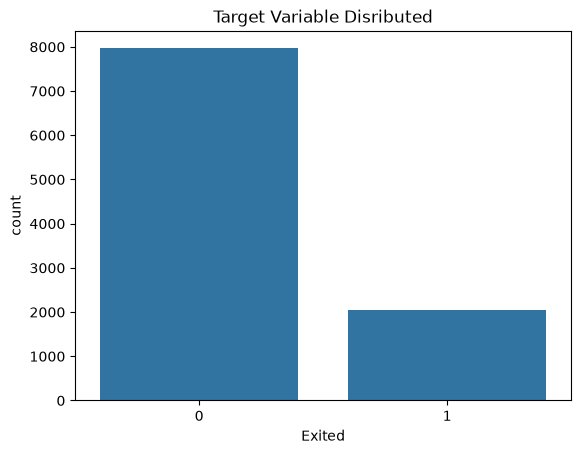

<Figure size 640x480 with 0 Axes>

In [46]:
sns.countplot(x=df.Exited)
plt.title('Target Variable Disributed')
plt.show()

plt.savefig('images/target_variable_distributiion.png')

`Exploratory Data Analysis`

**Univariate Categorical Analysis**

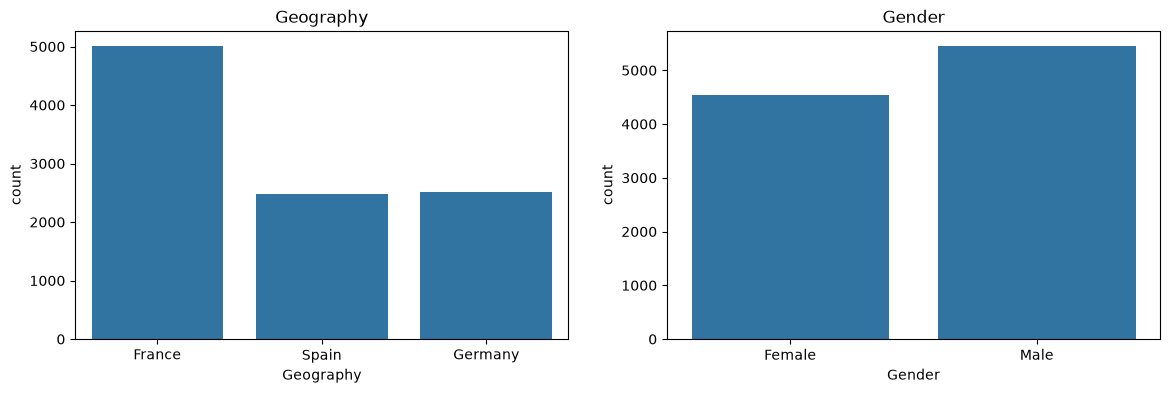

<Figure size 640x480 with 0 Axes>

In [48]:
fig,ax = plt.subplots(1,2,figsize=(14,4))

for i,col in enumerate(categorical_columns[1:]):
  sns.countplot(x=df[col],ax=ax[i])
  ax[i].set_title(col)


plt.show()

plt.savefig('images/categorical_columns_distribution.png')

**Univariate Numerical Analysis**

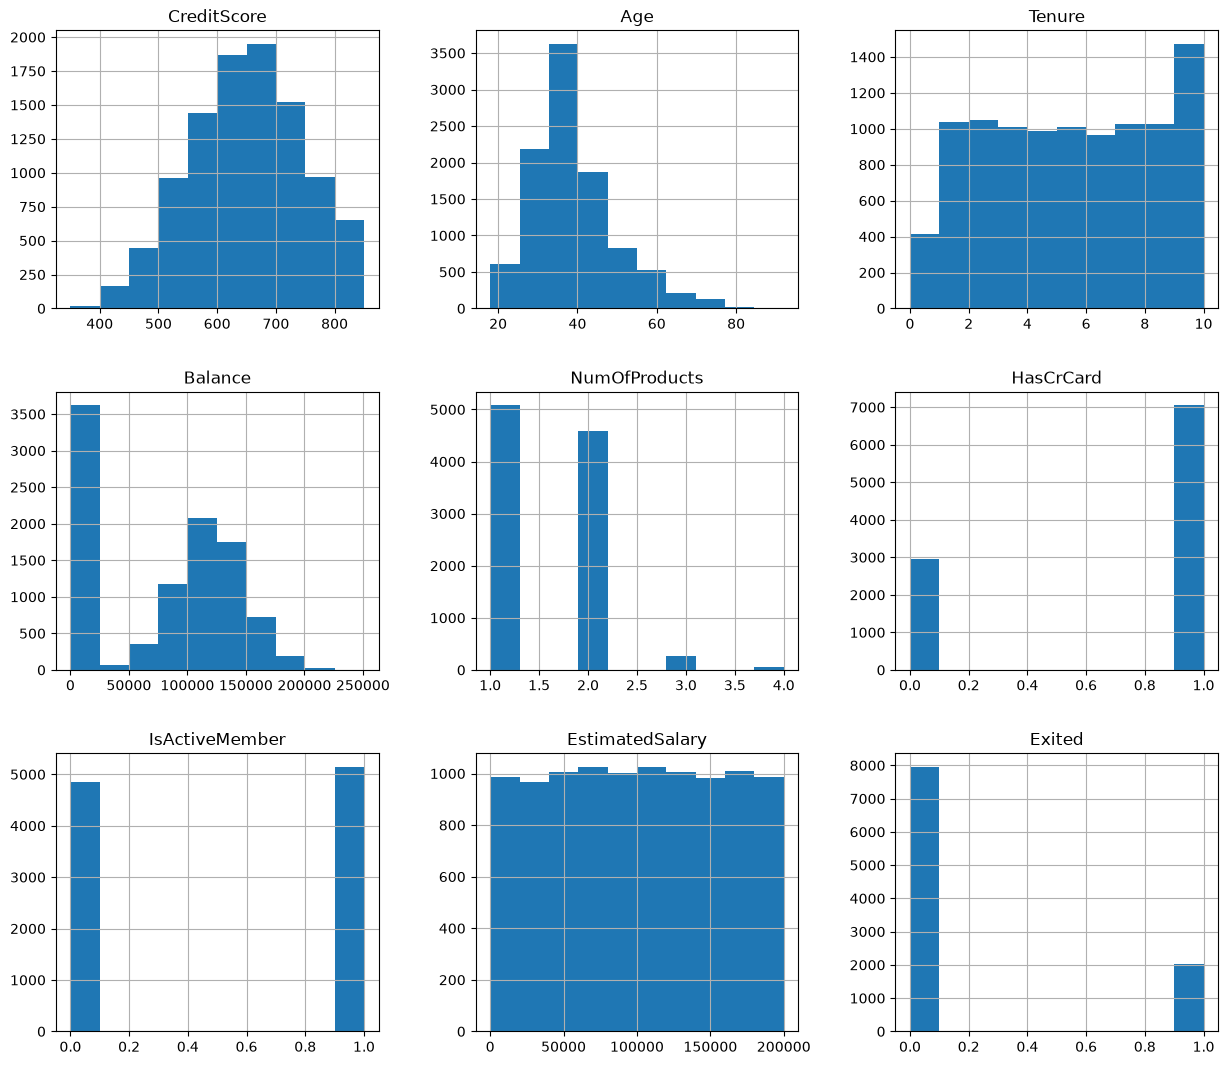

<Figure size 640x480 with 0 Axes>

In [47]:
numerical_columns = df.select_dtypes(exclude='object').columns.tolist()


df[numerical_columns].hist(figsize=(15,13))

plt.show()

plt.savefig('images/numerical_columns_distribution.png')

**Bivariate Analysis**

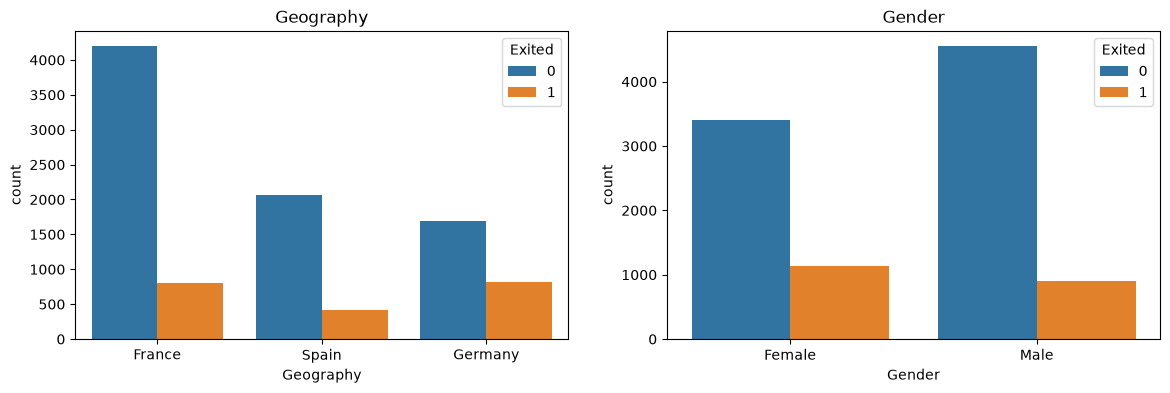

In [16]:
fig,ax = plt.subplots(1,2,figsize=(14,4))

for i,col in enumerate(categorical_columns[1:]):
  sns.countplot(x=df[col],ax=ax[i],hue=df.Exited)
  ax[i].set_title(col)


plt.show()

In [45]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

KeyError: 'CustomerId'

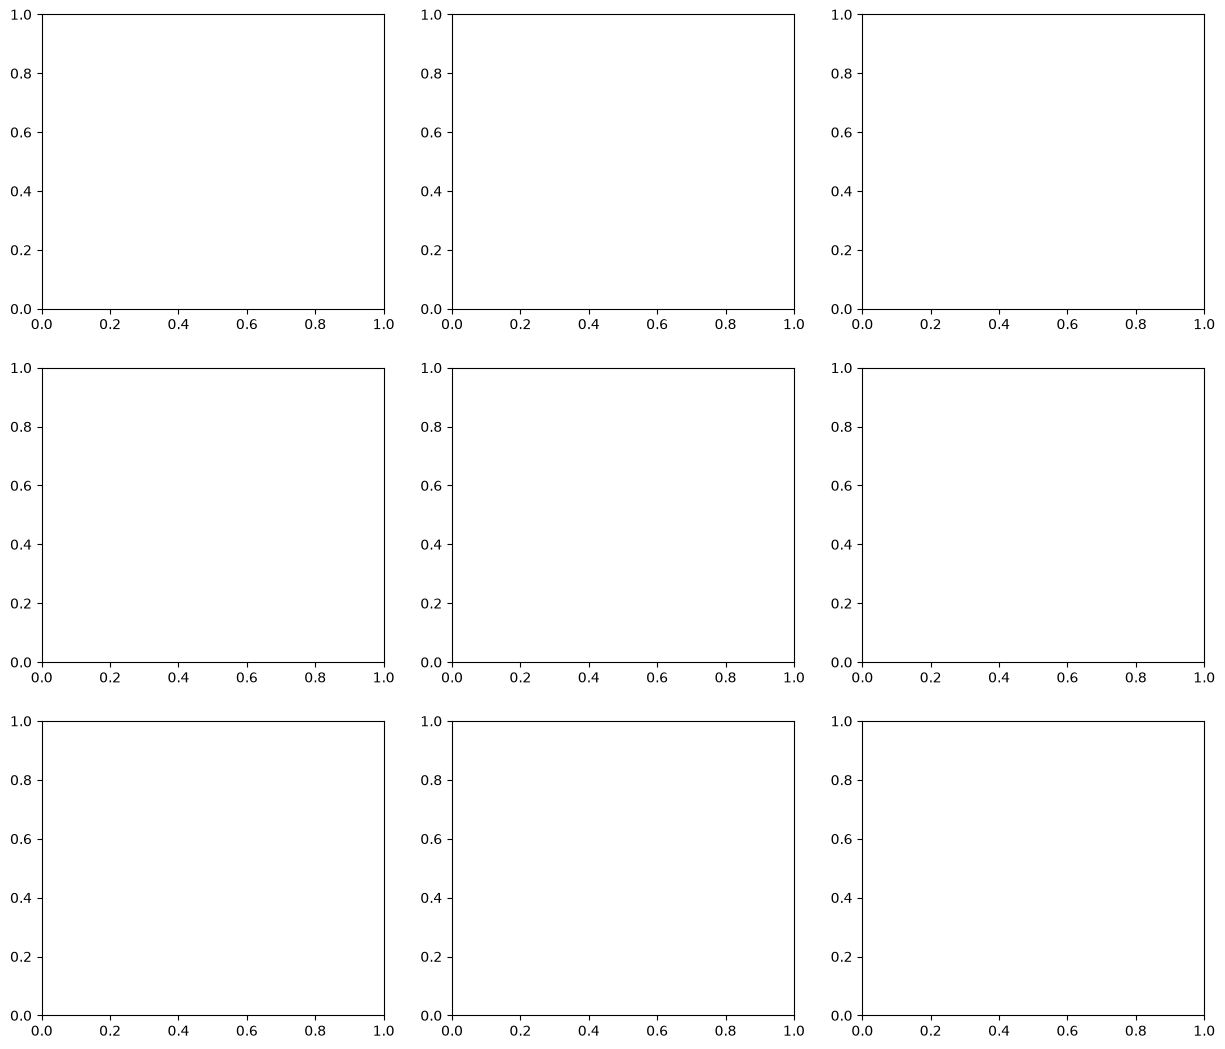

In [44]:
fig,ax = plt.subplots(3,3,figsize=(15,13))

ax = ax.flatten()

for i,col in enumerate(numerical_columns[:-1]):
  sns.kdeplot(
    x=df[col],
    hue=df['Exited'],
    # palette='coolwarm',
    ax=ax[i]
  )
  ax[i].set_title(col)
  
plt.tight_layout()
plt.show()
  
plt.savefig('images/eda_numerical.png')

**Identifying Outliers**

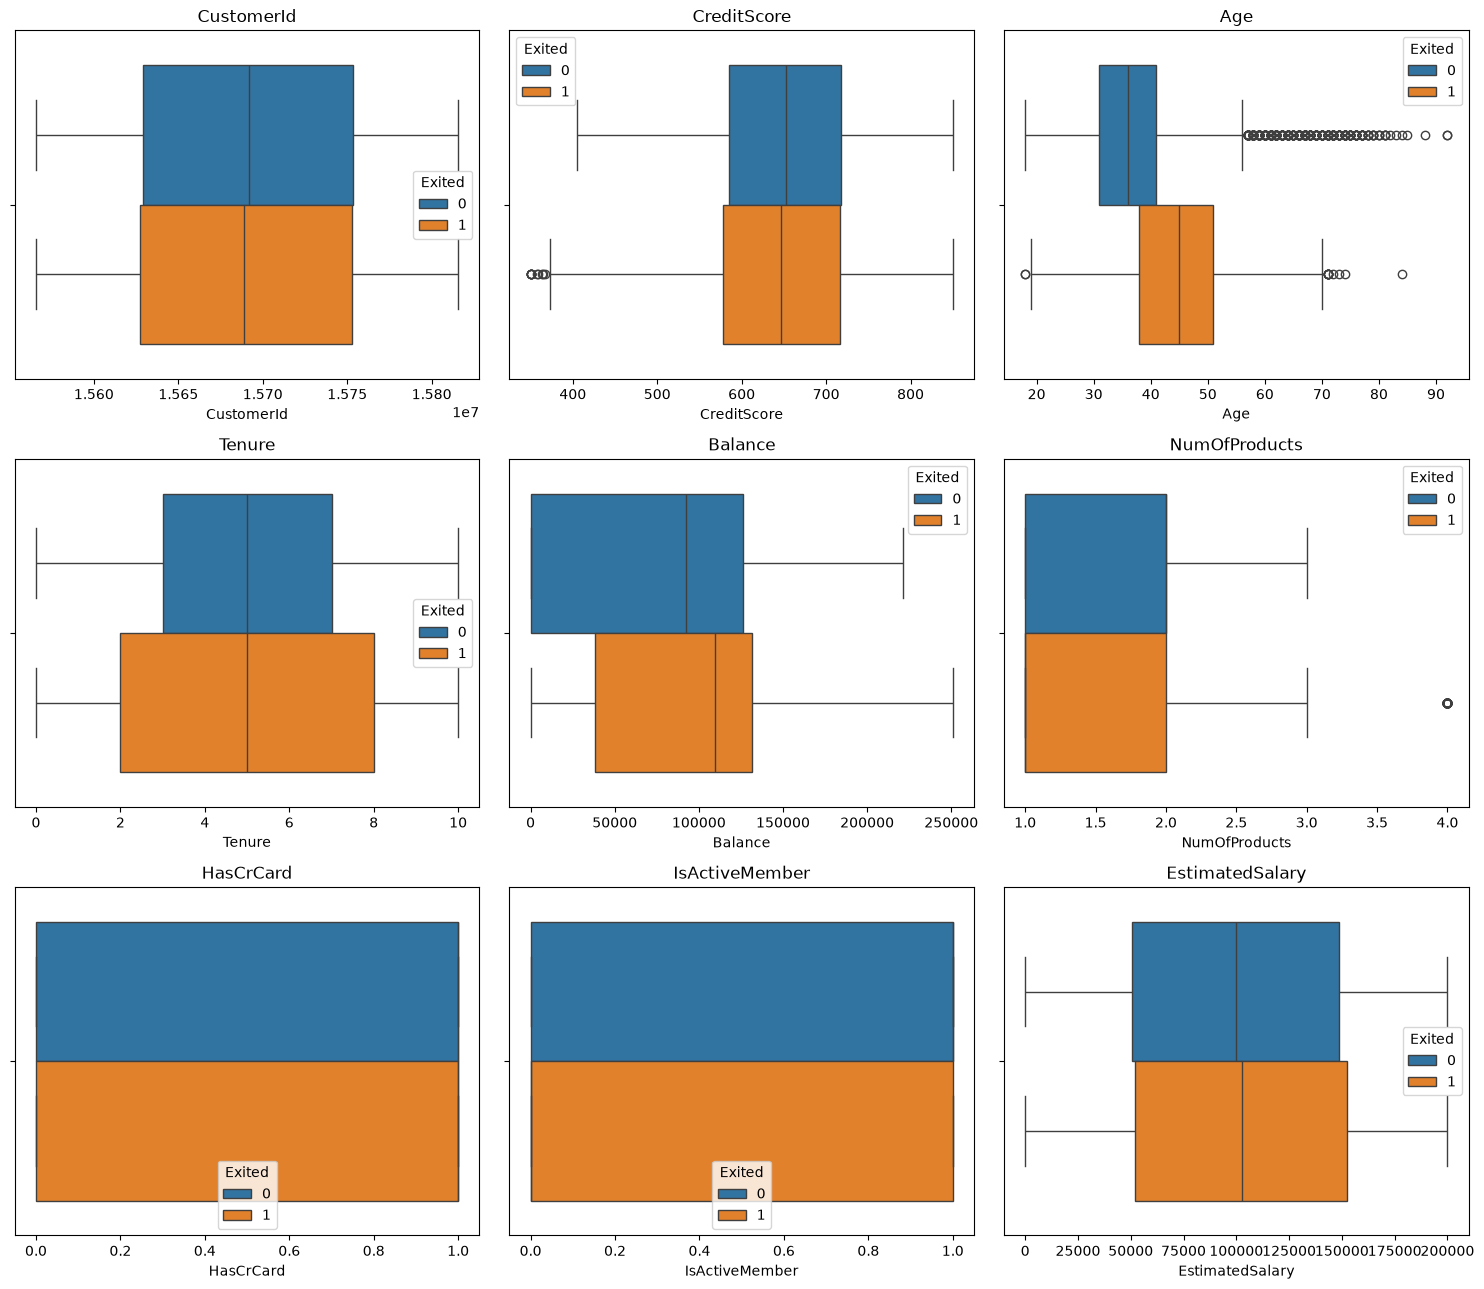

In [18]:
fig,ax = plt.subplots(3,3,figsize=(15,13))

ax = ax.flatten()

for i,col in enumerate(numerical_columns[:-1]):
  sns.boxplot(
    x=df[col],
    hue=df['Exited'],
    # palette='coolwarm',
    ax=ax[i]
  )
  ax[i].set_title(col)
  
plt.tight_layout()
plt.show()
  


In [19]:
df.drop(columns=['CustomerId','Surname'],axis=1,inplace=True)

**Feature Transformation**

In [20]:
log_cols = ['Age']
normalize_cols = ['CreditScore','Balance','EstimatedSalary']

ohe_columns = ['Geography','Gender']

In [21]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

log_transformers = FunctionTransformer(np.log1p,feature_names_out="one-to-one")

preprocessor = ColumnTransformer(
  transformers=[
    ('age_log',log_transformers,log_cols),
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_columns),
    ('scaler',StandardScaler(),normalize_cols)
  ],
  remainder='passthrough'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age_log', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
  df.drop(columns='Exited',axis=1),
  df['Exited'],
  test_size=0.2,
  random_state=42
)

In [23]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

In [24]:
x_train.shape,x_train_transformed.shape

((8000, 10), (8000, 11))

In [25]:
feature_names = preprocessor.get_feature_names_out()

In [26]:
feature_names

array(['age_log__Age', 'ohe__Geography_Germany', 'ohe__Geography_Spain',
       'ohe__Gender_Male', 'scaler__CreditScore', 'scaler__Balance',
       'scaler__EstimatedSalary', 'remainder__Tenure',
       'remainder__NumOfProducts', 'remainder__HasCrCard',
       'remainder__IsActiveMember'], dtype=object)

In [27]:
x_train_transformed_df = pd.DataFrame(x_train_transformed,columns=feature_names)
x_test_transformed_df = pd.DataFrame(x_test_transformed,columns=feature_names)


`Feature Selection `

In [28]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(x_train_transformed_df,y_train,random_state=42)

mi = pd.Series(mi_scores,index=feature_names)

mi = mi.sort_values(ascending=False)

print(mi)


remainder__NumOfProducts     0.078896
age_log__Age                 0.065469
scaler__Balance              0.013271
ohe__Geography_Germany       0.011670
remainder__IsActiveMember    0.011189
ohe__Geography_Spain         0.005380
ohe__Gender_Male             0.004116
scaler__EstimatedSalary      0.003589
scaler__CreditScore          0.003554
remainder__Tenure            0.002849
remainder__HasCrCard         0.000000
dtype: float64


In [29]:
drop_column = ['remainder__HasCrCard']

x_train_transformed_df.drop(columns=drop_column,axis=1,inplace=True)
x_test_transformed_df.drop(columns=drop_column,axis=1,inplace=True)

`Handling Imbalanced Dataset using Baseline Model`

In [30]:
from sklearn.metrics import *

class ClassificationMetricEvaluation:

    def __init__(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred

    def evaluate(self):
        return {
            "Accuracy": accuracy_score(self.y_true, self.y_pred),
            "Precision": precision_score(self.y_true, self.y_pred),
            "Recall": recall_score(self.y_true, self.y_pred),
            "F1 Score": f1_score(self.y_true, self.y_pred),
        }

In [31]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression(class_weight='balanced')

lg_model.fit(x_train_transformed_df,y_train)

lg_predict = lg_model.predict(x_test_transformed_df)


cm = ClassificationMetricEvaluation(y_test,lg_predict)

results = cm.evaluate()

for metric, score in results.items():
    print(f"{metric:<12}: {score:.4f}")

Accuracy    : 0.7125
Precision   : 0.3790
Recall      : 0.7252
F1 Score    : 0.4978


**Handling Imbalanced dataset using smote method**

In [32]:
from imblearn.over_sampling import SMOTE


# Applying smote only on training data

smote = SMOTE(random_state=42)

x_train_smote,y_train_smote = smote.fit_resample(x_train_transformed_df,y_train)

print('Before Smoting',y_train.value_counts())

print('After smoting : ',y_train_smote.value_counts())

Before Smoting Exited
0    6356
1    1644
Name: count, dtype: int64
After smoting :  Exited
0    6356
1    6356
Name: count, dtype: int64


In [33]:
logistic_regression = LogisticRegression()

logistic_regression.fit(x_train_smote,y_train_smote)

logistic_regression_pred = logistic_regression.predict(x_test_transformed_df)

cm = ClassificationMetricEvaluation(y_test,logistic_regression_pred)

results = cm.evaluate()

for metric, score in results.items():
    print(f"{metric:<12}: {score:.4f}")

Accuracy    : 0.7175
Precision   : 0.3838
Recall      : 0.7226
F1 Score    : 0.5013


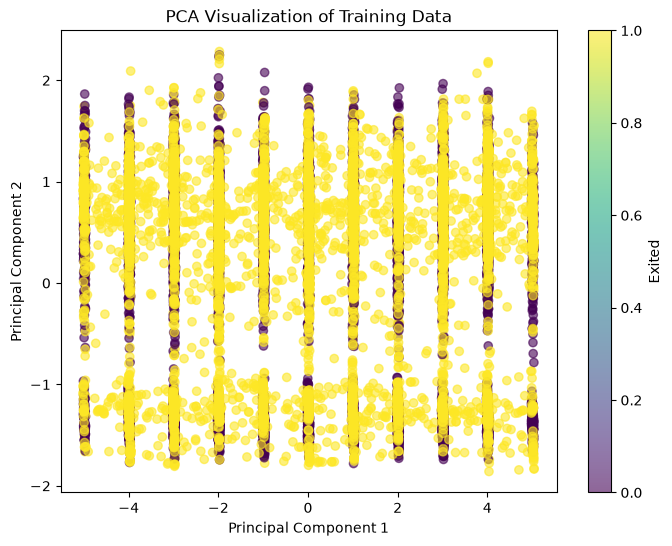

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(x_train_smote)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train_smote,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Training Data")
plt.colorbar(label="Exited")
plt.show()

`Automatically select best model`

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.svm import SVC

In [36]:
models = {
  "Logistic Regression" : LogisticRegression(random_state=42),
  "Decision Tree" : DecisionTreeClassifier(random_state=42),
  "Random Forest" : RandomForestClassifier(random_state=42),
  "KNN" : KNeighborsClassifier(),
  "SVM" : SVC(probability=True,random_state=42),
  "XGBoost":XGBClassifier(random_state=42),
  "LightGBM" : LGBMClassifier(random_state=42),
  "CatBoost" : CatBoostClassifier(verbose=0,random_state=42)
}

In [37]:
for model_name,model in models.items():
  
  model.fit(x_train_smote,y_train_smote)
  
  y_train_pred = model.predict(x_train_smote)
  
  y_test_pred = model.predict(x_test_transformed_df)
  
  print(f'----------- {model_name} --------')
  print('Training : ')
  cm = ClassificationMetricEvaluation(y_train_smote,y_train_pred)

  results = cm.evaluate()

  for metric, score in results.items():
      print(f"{metric:<12}: {score:.4f}")
  
  print('Testing : ')
  cm = ClassificationMetricEvaluation(y_test,y_test_pred)

  results = cm.evaluate()

  for metric, score in results.items():
      print(f"{metric:<12}: {score:.4f}")
      
  

----------- Logistic Regression --------
Training : 
Accuracy    : 0.7148
Precision   : 0.7116
Recall      : 0.7223
F1 Score    : 0.7169
Testing : 
Accuracy    : 0.7175
Precision   : 0.3838
Recall      : 0.7226
F1 Score    : 0.5013
----------- Decision Tree --------
Training : 
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
F1 Score    : 1.0000
Testing : 
Accuracy    : 0.7665
Precision   : 0.4305
Recall      : 0.5827
F1 Score    : 0.4951
----------- Random Forest --------
Training : 
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
F1 Score    : 1.0000
Testing : 
Accuracy    : 0.8430
Precision   : 0.6015
Recall      : 0.5954
F1 Score    : 0.5985
----------- KNN --------
Training : 
Accuracy    : 0.8955
Precision   : 0.8361
Recall      : 0.9840
F1 Score    : 0.9040
Testing : 
Accuracy    : 0.7085
Precision   : 0.3578
Recall      : 0.6081
F1 Score    : 0.4505
----------- SVM --------
Training : 
Accuracy    : 0.7659
Precision   : 0.7594
Recall      : 0.7783


In [38]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': randint(100, 600),
    'learning_rate': uniform(0.01, 0.19),
    'max_depth': randint(3, 15),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2)
}


random_search = RandomizedSearchCV(
  estimator = LGBMClassifier(random_state=42),
  param_distributions=param_dist,
  n_iter=50,
  scoring='f1',
  cv=5,
  random_state=42,
  n_jobs=-1,
  verbose=2
)

random_search.fit(x_train_smote,y_train_smote)

print(random_search.best_score_)
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 6356, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [39]:
"""
0.8791024060919426
{'colsample_bytree': np.float64(0.9771638815650077), 'learning_rate': np.float64(0.07140855708394349), 'max_depth': 10, 'min_child_samples': 61, 'n_estimators': 212, 'num_leaves': 81, 'reg_alpha': np.float64(1.9435641654419213), 'reg_lambda': np.float64(1.9248945898842225), 'subsample': np.float64(0.7007129183301457)}
"""

"\n0.8791024060919426\n{'colsample_bytree': np.float64(0.9771638815650077), 'learning_rate': np.float64(0.07140855708394349), 'max_depth': 10, 'min_child_samples': 61, 'n_estimators': 212, 'num_leaves': 81, 'reg_alpha': np.float64(1.9435641654419213), 'reg_lambda': np.float64(1.9248945898842225), 'subsample': np.float64(0.7007129183301457)}\n"

In [40]:

best_model = LGBMClassifier(
    random_state=42,
    **random_search.best_params_
)

best_model.fit(x_train_smote,y_train_smote)
  
y_train_pred = best_model.predict(x_train_smote)

y_test_pred = best_model.predict(x_test_transformed_df)

print('Training : ')
cm = ClassificationMetricEvaluation(y_train_smote,y_train_pred)

results = cm.evaluate()

for metric, score in results.items():
    print(f"{metric:<12}: {score:.4f}")

print('Testing : ')
cm = ClassificationMetricEvaluation(y_test,y_test_pred)

results = cm.evaluate()

for metric, score in results.items():
    print(f"{metric:<12}: {score:.4f}")


[LightGBM] [Info] Number of positive: 6356, number of negative: 6356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [41]:
import pickle

with open('best_model.pkl','wb') as file:
  pickle.dump(best_model,file)
  
with open('preprocessor.pkl','wb') as file:
  pickle.dump(preprocessor,file)
  
x_train_transformed_df.to_csv('transformed_train.csv')
x_test_transformed_df.to_csv('transformed_test.csv')

In [42]:
print(x_train_transformed_df.shape)
print(x_train_transformed_df.columns.tolist())

(8000, 10)
['age_log__Age', 'ohe__Geography_Germany', 'ohe__Geography_Spain', 'ohe__Gender_Male', 'scaler__CreditScore', 'scaler__Balance', 'scaler__EstimatedSalary', 'remainder__Tenure', 'remainder__NumOfProducts', 'remainder__IsActiveMember']
